# 4. Model Evaluation & Prediction

Evaluate and compare trained models stored in MLflow, and perform
inference on the fixed test dataset and custom images.

**No training or fine-tuning occurs in this notebook.**

## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [MLflow Connection](#2-mlflow-connection)
3. [Run Listing](#3-run-listing)
4. [Model Selection](#4-model-selection)
5. [Model Loading](#5-model-loading)
6. [Evaluation on Fixed Test Set](#6-evaluation-on-fixed-test-set)
7. [Results Visualization](#7-results-visualization)
8. [Single Image / Folder Prediction](#8-single-image--folder-prediction)

## 1. Setup & Imports

In [1]:
%matplotlib inline
import mlflow
import pandas as pd
from pathlib import Path
from ultralytics import YOLO

from utils.config import (
    PREPROCESSED_DIR, TEST_DIR, CLASS_NAMES, NUM_CLASSES, MLFLOW_MODEL_NAME,
)
from utils.mlflow_helpers import (
    setup_mlflow, list_runs, load_model_from_run,
    list_registered_model_versions, load_model_from_registry,
)
from utils.training_helpers import (
    get_device, evaluate_model, visualize_predictions,
    predict_single, predict_directory,
)

/home/paul/.pyenv/versions/3.10.14/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = get_device()

Device : GPU
  GPU  : NVIDIA GeForce MX230
  VRAM : 4.2 GB


## 2. MLflow Connection

In [3]:
experiment = setup_mlflow()

MLflow tracking URI : http://127.0.0.1:5000
Experiment          : tools_detection
Experiment ID       : 652288683939291895


## 3. Run Listing

Display all registered runs with their hyperparameters and metrics.

In [4]:
runs_df = list_runs()

if not runs_df.empty:
    # Select relevant columns for display
    display_cols = ["run_id"]
    if "tags.mlflow.runName" in runs_df.columns:
        display_cols.append("tags.mlflow.runName")

    param_cols = [c for c in runs_df.columns if c.startswith("params.")]
    metric_cols = [c for c in runs_df.columns if c.startswith("metrics.")]
    display_cols += param_cols + metric_cols

    display(runs_df[display_cols])
else:
    print("No runs available. Train a model first (Notebook 3).")

,run_id,tags.mlflow.runName,params.freeze_epochs,params.job_id,params.source,params.learning_rate,params.base_model,params.device,params.img_size,params.batch_size,...,metrics.epoch_recall,metrics.train_box_loss,metrics.val_dfl_loss,metrics.train_cls_loss,metrics.train_dfl_loss,metrics.precision,metrics.mAP50-95,metrics.epoch_precision,metrics.val_cls_loss,metrics.f1
0,ebd619bde5674064912f75d1bc6944e8,api_finetune_job_6,0,6,api,0.0001,/home/paul/universidad/septimo/IA/final_proyec...,0,640,8,...,0.28295,2.43030,1.77920,2.67450,1.86410,0.7260,0.1842,0.72579,2.21380,NaN
1,e088cd76dda14babbdd1fcf49b12dcc5,finetune_dataset_4,None,None,None,0.001,None,None,640,8,...,0.70449,0.49093,1.06490,0.52699,0.98842,0.7924,0.6436,0.80221,0.91988,0.7459
2,f85cc08a85a845ca8b06e7b9b5d0141f,api_finetune_job_5,0,5,api,0.0001,/home/paul/universidad/septimo/IA/final_proyec...,0,640,8,...,0.91947,0.54480,0.97116,0.58878,1.03540,0.8424,0.8215,0.84376,0.46682,NaN
3,1831a6cf214a47b5b16f188957e7e591,api_finetune_job_4,0,4,api,0.0001,/home/paul/universidad/septimo/IA/final_proyec...,0,640,8,...,0.71791,0.53961,0.96754,0.64272,1.02650,0.8505,0.7579,0.93117,0.52133,NaN
4,ebc630ac3b8f47e3b78ed363e11620e6,api_finetune_job_2,0,2,api,0.0001,None,auto,640,8,...,0.79713,0.55201,0.96918,0.59132,1.02130,0.9202,0.7608,0.92397,0.45993,NaN
5,69a4fb1fb1d64a75916970f3f6a999d1,api_finetune_job_1,3,1,api,0.0001,None,auto,640,4,...,0.83137,0.63635,1.02560,0.83463,1.09250,0.9359,0.7834,0.93605,0.65258,NaN
6,4d068e32429a497ea84ff64fe1c2e3af,finetune_dataset_2_with848e1a7c4c6c405aa95c282...,None,None,None,0.001,None,None,640,8,...,0.75062,0.77123,1.21620,0.76322,1.23060,0.8550,0.6442,0.85498,0.79714,0.7993
7,848e1a7c4c6c405aa95c2823401d3145,finetune_dataset_1,None,None,None,0.001,None,None,640,8,...,0.76676,0.65303,1.18060,0.62811,1.15670,0.8364,0.6538,0.83793,0.78039,0.8006
8,228014a921414f9d944c114c03dfae3e,bootstrap_transfer_learning,None,None,None,0.01,None,None,640,8,...,0.45451,1.05990,1.57740,1.90870,1.41990,0.5318,0.3187,0.53319,2.14000,0.4915


## 4. Model Selection

**Option A** — Load the latest (or a specific) version from the MLflow Model
Registry.  This is the recommended approach.

**Option B** — Paste a `run_id` from the table above to load a specific run.

In [ ]:
# ── Option A: Load from Model Registry (recommended) ──
versions_df = list_registered_model_versions(MLFLOW_MODEL_NAME)
if not versions_df.empty:
    display(versions_df)
else:
    print("No registered versions found. Use Option B (run_id) instead.")

## 5. Model Loading

Download the model artifact from MLflow and load it for inference.
Use **one** of the two cells below.

In [ ]:
# ── Option A: Load from registry (latest or specific version) ──
MODEL_VERSION = None  # Set to e.g. "2" for a specific version, None = latest

model_path = load_model_from_registry(MLFLOW_MODEL_NAME, version=MODEL_VERSION)
model = YOLO(str(model_path))
print(f"Model loaded from: {model_path}")

In [ ]:
# ── Option B: Load by run_id ──
# SELECTED_RUN_ID = "848e1a7c4c6c405aa95c2823401d3145"  # <-- paste run_id here
# model_path = load_model_from_run(SELECTED_RUN_ID)
# model = YOLO(str(model_path))
# print(f"Model loaded from: {model_path}")

## 6. Evaluation on Fixed Test Set

Run inference on **all** images in `data/pre_process/test/images`.
The test set is fixed and immutable.

In [7]:
metrics = evaluate_model(model)

print("\n── Test Set Metrics ──")
metrics_df = pd.DataFrame(metrics, index=["value"]).T
metrics_df.columns = ["Value"]
display(metrics_df)

Ultralytics YOLOv8.0.196 🚀 Python-3.10.14 torch-1.13.1+cu117 CUDA:0 (NVIDIA GeForce MX230, 4034MiB)
Model summary (fused): 168 layers, 3006428 parameters, 0 gradients, 8.1 GFLOPs
val: Scanning /home/paul/universidad/septimo/IA/final_proyect/notebooks/data/pre_process/test/labels.ca
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|████████
                   all        893       1558      0.836      0.768      0.845      0.654
Speed: 1.0ms preprocess, 21.7ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /home/paul/.pyenv/runs/detect/val17



── Test Set Metrics ──


,Value
mAP50,0.8449
mAP50-95,0.6538
precision,0.8364
recall,0.7677
f1,0.8006


## 7. Results Visualization

Visual sample of predictions on test images.

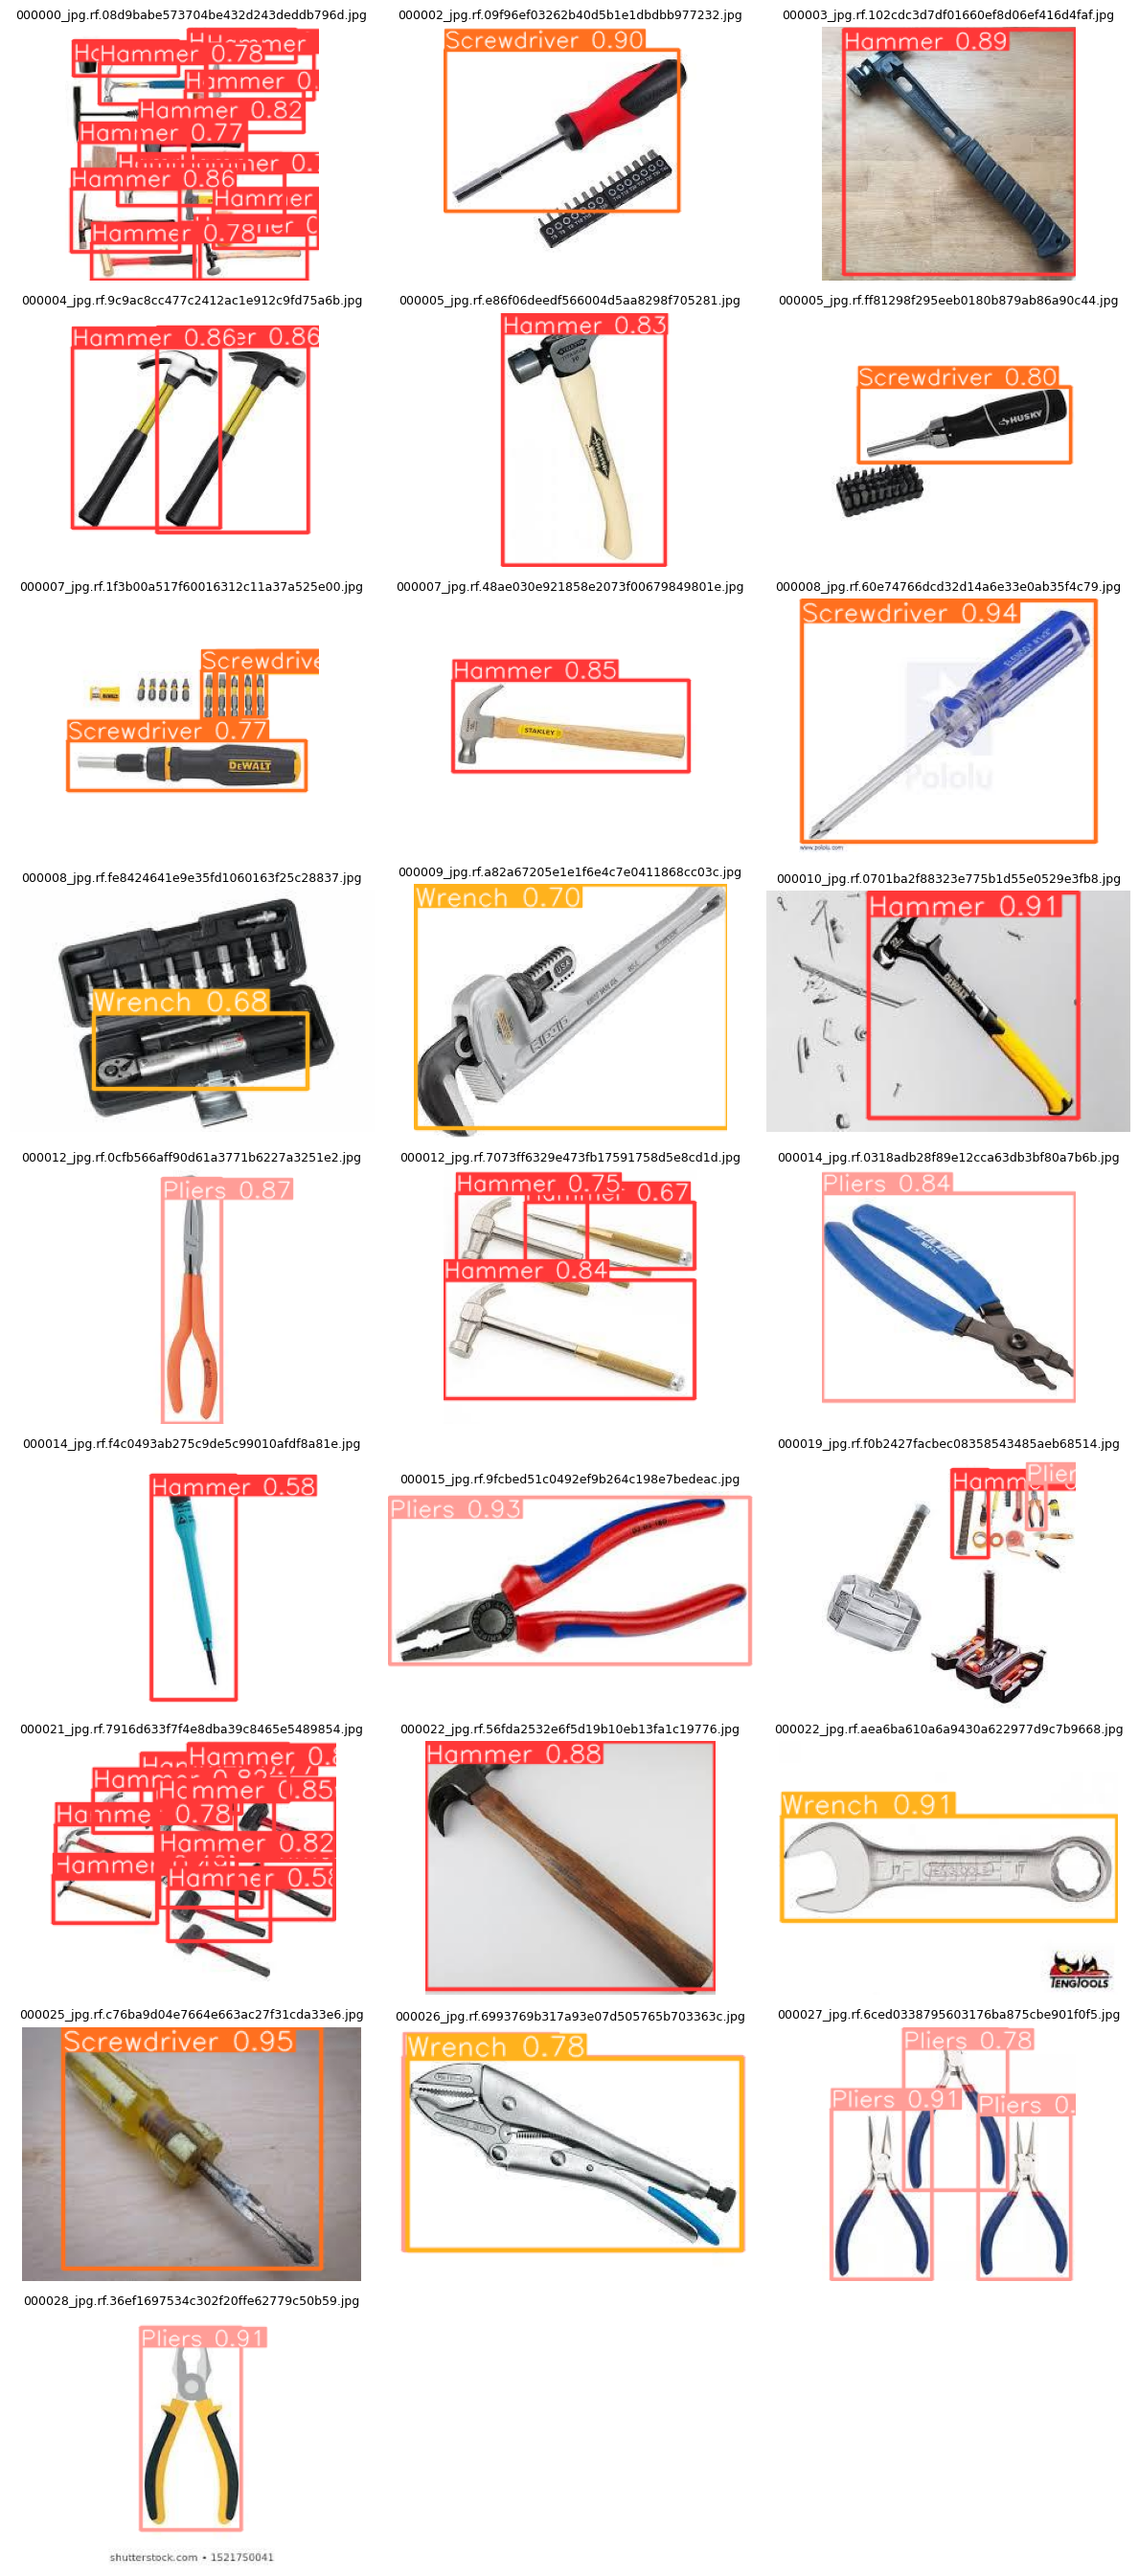

In [8]:
visualize_predictions(model, TEST_DIR / "images", num_images=25, conf=0.40)

## 8. Single Image / Folder Prediction

Run inference on a single image or an entire directory.
Displays bounding boxes, class names, and confidence scores.

### 8.1 Single Image

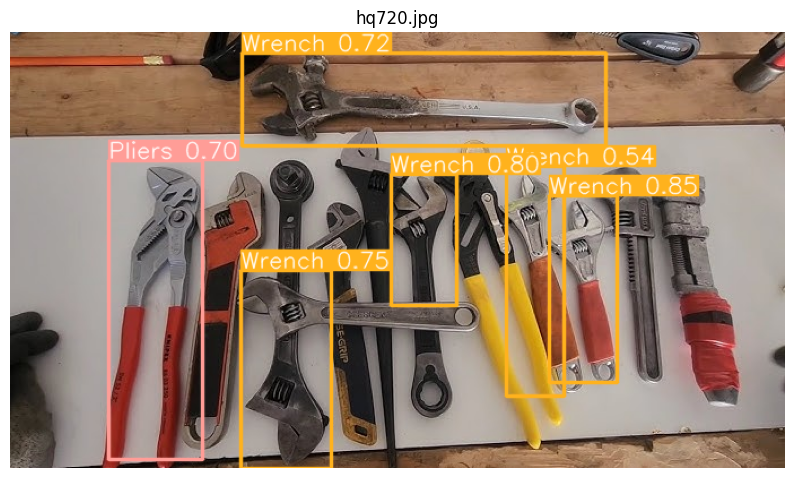

  Wrench                     conf=0.847  bbox=[477.3, 146.0, 537.2, 311.0]
  Wrench                     conf=0.802  bbox=[337.2, 126.0, 395.1, 242.5]
  Wrench                     conf=0.754  bbox=[204.6, 211.4, 284.7, 386.0]
  Wrench                     conf=0.718  bbox=[205.7, 19.9, 527.1, 101.3]
  Pliers                     conf=0.699  bbox=[87.0, 114.2, 170.5, 378.2]
  Wrench                     conf=0.536  bbox=[439.8, 119.8, 490.8, 322.9]


In [13]:
# ── Set image path ──
IMAGE_PATH = "images_prediction/hq720.jpg"

if IMAGE_PATH:
    detections = predict_single(model, IMAGE_PATH,640,0.5)
    for d in detections:
        print(f"  {d['class']:25s}  conf={d['confidence']:.3f}  bbox={[round(x,1) for x in d['bbox']]}")
else:
    print("Set IMAGE_PATH to run single-image prediction.")

### 8.2 Folder Prediction

Processed 4 images — 35 detections

81KlMfIUS2L._AC_UF894,1000_QL80_.jpg:
  Screwdriver                conf=0.936
  Screwdriver                conf=0.931
  Screwdriver                conf=0.921
  Screwdriver                conf=0.895
  Screwdriver                conf=0.839
  Screwdriver                conf=0.839
  Screwdriver                conf=0.820
  Screwdriver                conf=0.716
  Wrench                     conf=0.546
  Screwdriver                conf=0.428
  Hammer                     conf=0.411
  Wrench                     conf=0.361
  Wrench                     conf=0.323

hq720.jpg:
  Wrench                     conf=0.847
  Wrench                     conf=0.802
  Wrench                     conf=0.754
  Wrench                     conf=0.718
  Pliers                     conf=0.699
  Wrench                     conf=0.536
  Wrench                     conf=0.473
  Wrench                     conf=0.382
  Wrench                     conf=0.381
  Wrench                     conf=

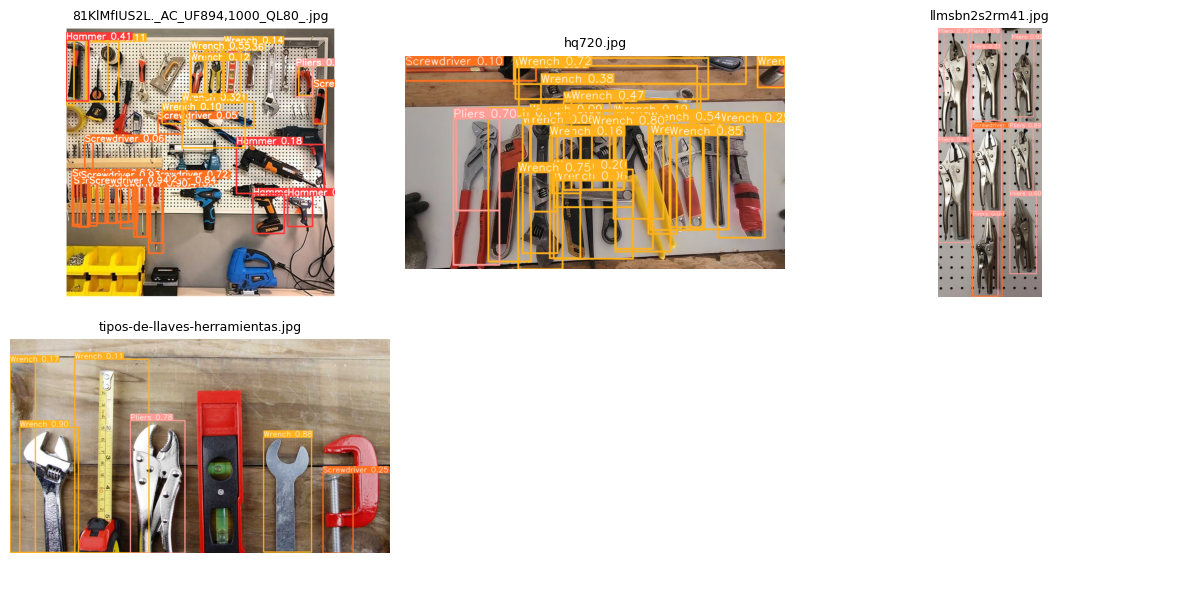

In [14]:
# ── Set folder path ──
FOLDER_PATH = "images_prediction"

if FOLDER_PATH:
    all_dets = predict_directory(model, FOLDER_PATH)
    # Show first 5 images' results
    for fname, dets in list(all_dets.items())[:5]:
        print(f"\n{fname}:")
        for d in dets:
            print(f"  {d['class']:25s}  conf={d['confidence']:.3f}")

    # Visualize a subset
    visualize_predictions(model, FOLDER_PATH, num_images=6, conf=0.05)
else:
    print("Set FOLDER_PATH to run folder prediction.")